# Semana 7 — Arquitecturas modernas para forecasting

**Objetivo.** Comparar un baseline, LSTM, N-BEATS y un Transformer con gating inspirado en TFT, y estudiar transferencia a sensores no vistos.

- **Dataset:** `data/07_traffic_pems/traffic_pems.csv`
- **Dimensión:** 63,360 × 967; 963 sensores
- **Duración:** 5 horas
- **Seed:** 42; ejecución CPU

**Contrato de secciones:** Sección 0: Configuración y contrato de datos; Sección 1: Análisis previo; Sección 2: Estrategia de validación; Sección 3: Modelado; Sección 4: Análisis posterior; Sección 5: Lecciones metodológicas; Sección 6: Ejercicios.

**Lectura ejecutiva.** Este notebook responde una pregunta de negocio concreta: si mañana se instala un sensor de tráfico en una vía sin historial, ¿puede un modelo entrenado con otros sensores pronosticar su ocupación? La respuesta se construye con datos reales de PeMS-SF (963 sensores), un split por sensor 770/193 y una cohorte CPU 48/24. El resultado ejecutado muestra que la transferencia funciona: el mejor modelo, **TFT-like**, alcanza **MAE 0.013122** en la cohorte ejecutada. No obstante, atención no es geografía: sin coordenadas ni red vial, el modelo transfiere patrones temporales, no relaciones espaciales reales.


### Caso de negocio — Gestión de tráfico con sensores

Una ciudad gestiona su red vial con sensores que miden la ocupación (fracción de la vía ocupada) cada 10 minutos. El problema operativo: **cuando se instala un sensor en una vía nueva, no hay historial**, pero la gestión de tráfico necesita pronósticos desde el primer día (semaforización adaptativa, detección de incidentes, información al conductor). La hipótesis de este notebook es que un modelo entrenado con otros sensores puede transferir el conocimiento aprendido —patrones diarios, semanales y de persistencia— a esos sensores nuevos.

**Costo del error.** El costo no es simétrico ni directamente monetario: subestimar la ocupación puede significar no detectar una congestión; sobreestimarla activa protocolos innecesarios. Con la escala [0,1] del dataset, un MAE de ≈0.013 (valor del mejor modelo en la cohorte) equivale a ≈1.3 puntos porcentuales de ocupación de error medio. La métrica importa en términos de *decisión*: qué umbrales de incidentes se activan y con qué confianza.

### Pregunta guía

**¿La transferencia entre sensores funciona sin features geográficas reales?**

El dataset PeMS-SF no incluye coordenadas ni red vial. A lo largo del notebook evaluaremos si un modelo entrenado con sensores train predice sensores test nunca vistos y cuantificaremos cuánto de esa capacidad se debe a patrones temporales compartidos (transferencia real) frente a lo que exigiría información geográfica. La respuesta se resume en la *Decisión ejecutiva* de la Sección 3.

> *Este notebook modela ocupación agregada por sensor cada 10 minutos, no comportamiento individual de vehículos ni decisiones específicas de conductores. Las conclusiones aplican a gestión de red vial y monitoreo de sensores, no a inferencias causales sobre tráfico microscópico.*

### 0.1 Imports y reproducibilidad

Modelos compactos en PyTorch, sin GPU.

Esta celda define el contrato de reproducibilidad del notebook: fijamos la `seed` 42 para `random`, `numpy` y `torch`, limitamos a 4 hilos de CPU y silenciamos warnings para que los mensajes visibles sean solo los resultados. La semilla garantiza que el shuffle de sensores, el particionado de batches y la inicialización de pesos sean deterministas: dos ejecuciones en la misma máquina deben producir los mismos números. En un entorno de negocio, esto es lo que permite auditar un resultado y comparar experimentos entre sí.


In [1]:
from __future__ import annotations
from pathlib import Path
import copy, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
# Seed global de reproducibilidad (contrato del curso: seed 42)
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.set_num_threads(4)
# CPU determinista con 4 hilos; se desactiva GPU explícitamente
warnings.filterwarnings("ignore"); sns.set_theme(style="whitegrid"); plt.rcParams["figure.figsize"]=(12,4); DEVICE=torch.device("cpu")

### 0.2 Ruta y tamaño

El archivo ancho ocupa ~408 MiB; se seleccionan columnas al cargar.

La lectura del CSV es el primer paso operativo: el archivo pesa ~408 MiB y tiene 967 columnas, por lo que cargarlo completo en memoria sería costoso. La estrategia es buscar el CSV en dos rutas candidatas (raíz del repo o `../data/`) y, más adelante, leer solo las columnas necesarias. Este patrón "rutas candidatas + lectura selectiva" es el mismo que se usaría en producción para no duplicar datos en memoria.


In [2]:
# Rutas candidatas: se busca el CSV desde la raíz del repo o desde notebooks/
CANDIDATES=[Path("data/07_traffic_pems/traffic_pems.csv"),Path("../data/07_traffic_pems/traffic_pems.csv")]
DATA_PATH=next((p for p in CANDIDATES if p.exists()),None); assert DATA_PATH
print(DATA_PATH.resolve(),DATA_PATH.stat().st_size/2**20)

/home/enrique/Escritorio/Curso_pronostico_series_temporales/course-timeseries-benchmarks-pro/data/07_traffic_pems/traffic_pems.csv 408.21919536590576


### 0.3 Schema

Se extraen metadatos y 963 sensores.

El dataset es ancho: cada columna `station_*` es un sensor (estación de medida) y las columnas `split`, `day_id`, `slot_10min`, `weekday_label` son metadatos. Entender este esquema es clave para el caso de negocio: los sensores son la unidad de negocio (cada uno mide la ocupación de una vía) y los metadatos temporales son posicionales, no fechas calendario.


In [3]:
# Esquema: 4 columnas de metadatos + 963 columnas de sensores = 967
columns=pd.read_csv(DATA_PATH,nrows=0).columns.tolist(); META=["split","day_id","slot_10min","weekday_label"]; SENSORS=[x for x in columns if x.startswith("station_")]
assert len(columns)==967 and len(SENSORS)==963
print(META,SENSORS[:5],SENSORS[-3:])

['split', 'day_id', 'slot_10min', 'weekday_label'] ['station_400000', 'station_400001', 'station_400009', 'station_400010', 'station_400015'] ['station_402088', 'station_402089', 'station_402090']


### 0.4 Split por sensor

770 train y 193 test, determinista.

Este es el split **completo** del curso: 770 sensores con historia para entrenar y 193 sensores "nuevos" que actuarán como test de transferencia. Al separar por sensor (columnas) y no por tiempo, simulamos el escenario real de instalar sensores en vías sin historial. El shuffle usa la `seed` 42, por lo que la asignación es determinista y reproducible. Es importante no confundir este split con la cohorte CPU 48/24 que se define más adelante: la cohorte es un subconjunto computacional del mismo split, no un split distinto.


In [4]:
# Split por sensor: baraja los 963 sensores con la seed y corta en 770/193
rng=np.random.default_rng(SEED); sensor_array=np.array(SENSORS); rng.shuffle(sensor_array); TRAIN_SENSORS=list(sensor_array[:770]); TEST_SENSORS=list(sensor_array[770:]); assert len(TRAIN_SENSORS)==770 and len(TEST_SENSORS)==193 and not set(TRAIN_SENSORS)&set(TEST_SENSORS)

In [5]:
# --- Aserción anti-leakage (split por sensor) ---
# Constantes con nombre: el split completo es 770/193 sensores
N_TRAIN_SENSORS = 770   # sensores con historial para entrenar
N_TEST_SENSORS = 193    # sensores nuevos sin historial (transferencia)
assert len(TRAIN_SENSORS) == N_TRAIN_SENSORS and len(TEST_SENSORS) == N_TEST_SENSORS
assert set(TRAIN_SENSORS) | set(TEST_SENSORS) == set(SENSORS)   # exhaustivo: cubre los 963
assert not (set(TRAIN_SENSORS) & set(TEST_SENSORS))             # disjunto: sin solapamiento
# Determinismo: la misma seed debe reproducir exactamente la misma partición
rng_check = np.random.default_rng(SEED)
order_check = np.array(SENSORS); rng_check.shuffle(order_check)
assert list(order_check[:770]) == TRAIN_SENSORS and list(order_check[770:]) == TEST_SENSORS
print("Anti-leakage OK: split por sensor determinista, 770 train / 193 test, sin solapamiento.")

Anti-leakage OK: split por sensor determinista, 770 train / 193 test, sin solapamiento.


### 0.5 Lectura selectiva

Para EDA/modelado CPU se cargan metadatos, 48 sensores train y 24 test. El split completo 770/193 queda definido; la cohorte es un subconjunto determinista con propósito computacional, no datos simulados.

**Cohorte CPU 48/24 ≠ split de datos.** La cohorte toma los primeros 48 sensores del split train y los primeros 24 del split test. Es un subconjunto del split completo 770/193, elegido para que el notebook pueda ejecutarse en CPU en un tiempo razonable. No es un split alternativo ni una muestra con reemplazo: cada sensor de la cohorte pertenece exactamente a su partición original, por lo que la medición de transferencia sigue siendo válida, solo que con menos sensores. Si el presupuesto computacional lo permite, el protocolo completo 770/193 está definido y listo para ejecutarse sin cambiar el código de modelado.


In [6]:
# Cohorte CPU: 48 sensores train + 24 sensores test (subconjunto del split 770/193)
LAB_TRAIN=TRAIN_SENSORS[:48]; LAB_TEST=TEST_SENSORS[:24]; usecols=META+LAB_TRAIN+LAB_TEST; df=pd.read_csv(DATA_PATH,usecols=usecols,dtype={x:"float32" for x in LAB_TRAIN+LAB_TEST}); print(df.shape,df.memory_usage(deep=True).sum()/2**20)

(63360, 76) 22.091846466064453


### 0.6 Contrato de filas

440 días × 144 slots.

El contrato de datos es una aserción explícita: 440 días × 144 slots de 10 minutos = 63,360 filas, sin valores nulos. En un flujo de producción, este tipo de aserción evita que un cambio silencioso en la fuente (filas duplicadas, nulos, granularidad distinta) invalide los resultados posteriores. La celda siguiente verifica el contrato antes de cualquier modelado.


In [7]:
# Contrato de filas: dimensiones, cardinalidad de día/slot y ausencia de nulos
assert df.shape[0]==63_360; assert df.day_id.nunique()==440; assert df.slot_10min.nunique()==144; assert not df.isna().any().any(); print(df.split.value_counts(),df.weekday_label.value_counts().sort_index())

split
train    38448
test     24912
Name: count, dtype: int64 weekday_label
1    8928
2    8208
3    9216
4    9360
5    9360
6    9072
7    9216
Name: count, dtype: int64


### 0.7 Sin fechas calendario

Se construye índice posicional, no fecha ficticia.

PeMS-SF no publica fechas calendario: solo `day_id`, `slot_10min` y `weekday_label`. Fabricar fechas sería una decisión metodológica incorrecta (un anti-patrón): introduciría vacaciones, festivos o efectos de calendario que no están en la fuente. En su lugar se usa un índice posicional `day_id*144 + slot_10min`, suficiente para estacionalidad diaria y semanal. Esta limitación es relevante para el caso de negocio: tampoco hay coordenadas geográficas de los sensores, por lo que el modelo solo puede aprender patrones temporales y correlaciones estadísticas, no distancias ni conectividad vial real.


In [8]:
# Índice posicional único: evita fabricar fechas calendario inexistentes
df["time_index"]=df.day_id*144+df.slot_10min; assert df.time_index.is_unique; print(df.time_index.min(),df.time_index.max())

0 63359


### 0.8 Rango de ocupación

Valores normalizados.

La ocupación está normalizada en [0, 1] (fracción de la vía ocupada). El output de la celda siguiente lo confirma: mediana ≈ 0.047 y percentil 99 ≈ 0.258. Esta escala acotada es importante para modelado: los errores MAE del orden de 0.013 deben interpretarse como ~1.3 puntos porcentuales de ocupación, no como errores relativos grandes. En términos de negocio, un error de ese tamaño permite priorizar la gestión de incidentes sin confundir magnitud.


In [9]:
# Distribución de la ocupación: escala [0,1] y cola derecha leve
df[LAB_TRAIN+LAB_TEST].stack().describe(percentiles=[.01,.5,.99])

count    4.561920e+06
mean     5.394367e-02
std      4.814699e-02
min      0.000000e+00
1%       2.300000e-03
50%      4.700000e-02
99%      2.584000e-01
max      1.000000e+00
dtype: float64

## 1. Análisis previo (pre-modeling)

La fuente carece de fechas calendario. `day_id`, `slot_10min` y `weekday_label` son las únicas coordenadas temporales observadas.

Esta sección responde preguntas de negocio antes de modelar: ¿qué patrón horario tiene el tráfico? ¿los sensores se comportan de forma parecida entre sí? ¿la serie es estacionaria? El análisis previo no entrena modelos; decide qué estructura temporal aprovechar (diaria, semanal) y qué riesgos asumir (sin geografía, outliers, cambios de nivel). Es la fase donde se detecta qué información existe de verdad y cuál no.


### 1.1 Sensor ejemplo

Dos semanas posicionales.

Elegimos el primer sensor de la cohorte train (`station_400137`, según el output de la celda de tests) y graficamos 14 días para ver el comportamiento bruto: ciclos diarios con picos y valles, probablemente con patrón laboral. Ver la serie antes de modelar es el equivalente a "leer el negocio": detectar si el sensor tiene estacionalidad clara, si hay valores planos (vía colapsada o sensor averiado) o si el nivel cambia entre semanas.


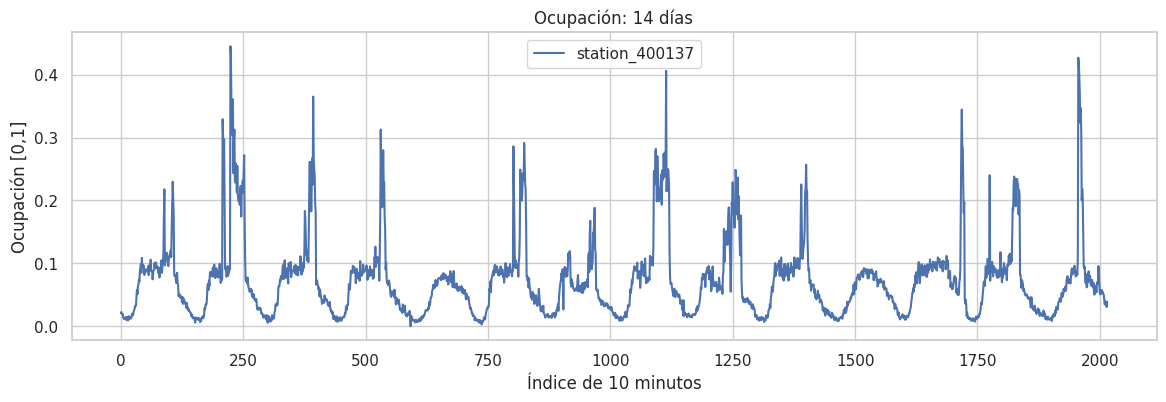

In [10]:
# Serie ejemplo: primeras 2 semanas (14*144 = 2016 slots de 10 min)
uid=LAB_TRAIN[0]; g=df.iloc[:144*14]; fig,ax=plt.subplots(figsize=(14,4)); ax.plot(g.time_index,g[uid],label=uid); ax.set(title="Ocupación: 14 días",xlabel="Índice de 10 minutos",ylabel="Ocupación [0,1]"); ax.legend(); plt.show()

### 1.2 Perfil intradiario

Media por slot.

Promediamos la ocupación de los 48 sensores train para cada slot de 10 minutos (0–143). El perfil intradiario muestra cuándo la red soporta más carga: esperablemente dos picos (mañana y tarde) en días laborables. Este perfil es una feature temporal implícita que los modelos deberían capturar; también sirve como referencia conceptual: si el modelo no puede superar al perfil medio, no está aprendiendo estructura diaria.


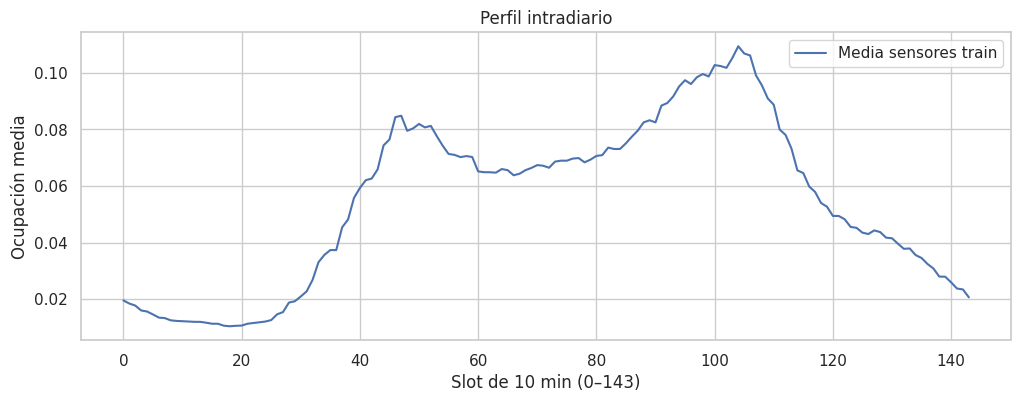

In [11]:
# Perfil intradiario: media por slot de 10 minutos sobre los 48 sensores train
prof=df.groupby("slot_10min")[LAB_TRAIN].mean().mean(axis=1); fig,ax=plt.subplots(); ax.plot(prof.index,prof,label="Media sensores train"); ax.set(title="Perfil intradiario",xlabel="Slot de 10 min (0–143)",ylabel="Ocupación media"); ax.legend(); plt.show()

### 1.3 Perfil semanal

Media por etiqueta de día.

La etiqueta `weekday_label` (1–7) permite comparar días. En tráfico, el patrón laboral frente a fin de semana es una de las señales más fuertes: la ocupación media de los días laborables suele superar a la del fin de semana. Confirmarlo aquí valida que la estacionalidad semanal es explotable y que la transferencia entre sensores tiene una base temporal común.


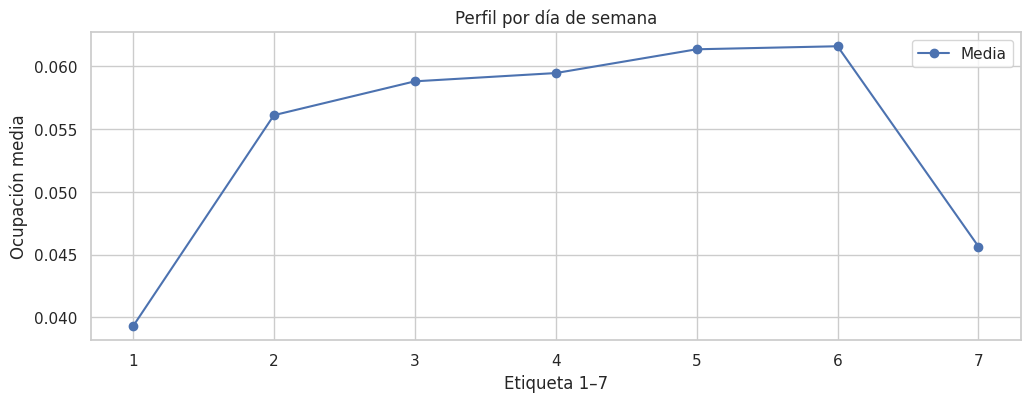

In [12]:
# Perfil semanal: media por etiqueta de día (1–7) sobre sensores train
prof=df.groupby("weekday_label")[LAB_TRAIN].mean().mean(axis=1); fig,ax=plt.subplots(); ax.plot(prof.index,prof,marker="o",label="Media"); ax.set(title="Perfil por día de semana",xlabel="Etiqueta 1–7",ylabel="Ocupación media"); ax.legend(); plt.show()

### 1.4 Correlación entre sensores

Matriz sobre 24 sensores train.

La correlación entre series de sensores mide si comparten dinámica temporal. Es la base estadística de la transferencia: si los sensores fueran independientes, un modelo entrenado en unos no tendría nada que aportar a otros. La matriz (y el índice de conectividad de la celda siguiente) aproxima esa relación usando correlación, no topología física: aquí no hay coordenadas, por lo que "cerca" significa "correlacionado", no "próximo geográficamente".


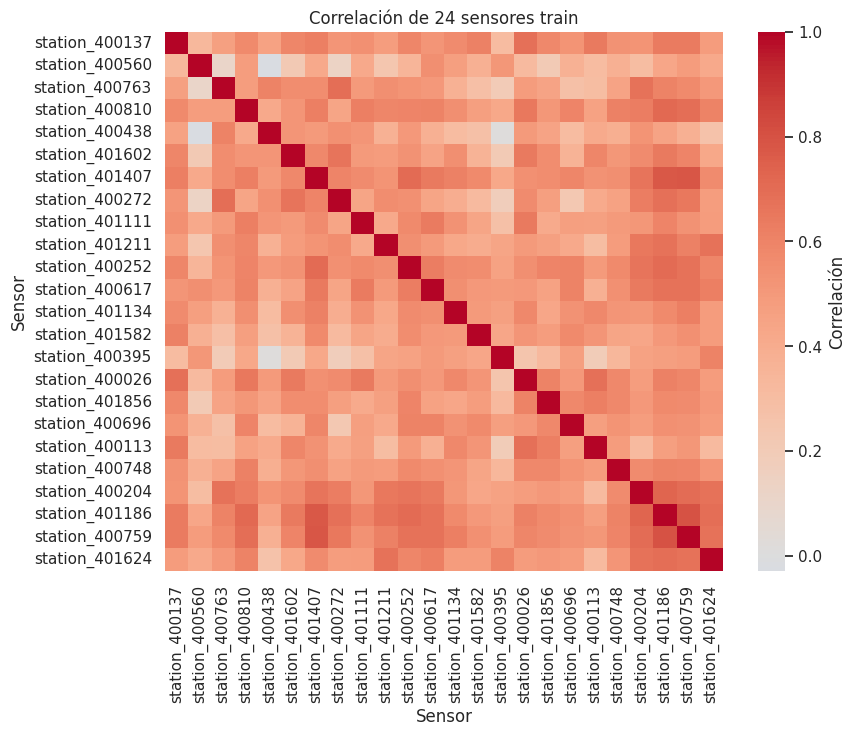

In [13]:
# Heatmap de correlación: 24 sensores train, orden del dataframe
corr=df[LAB_TRAIN[:24]].corr(); fig,ax=plt.subplots(figsize=(9,7)); sns.heatmap(corr,cmap="coolwarm",center=0,ax=ax,cbar_kws={"label":"Correlación"}); ax.set(title="Correlación de 24 sensores train",xlabel="Sensor",ylabel="Sensor"); plt.show()

### 1.5 Conectados y aislados

Conectividad = correlación absoluta media, no topología física.

El índice de conectividad resume cada fila de la matriz como correlación absoluta media con los demás sensores. El output muestra el sensor más conectado (`station_401186`, ≈0.616) y el más aislado (`station_400560`, ≈0.341). Esta variabilidad es una advertencia de negocio: no todos los sensores son igualmente predecibles por transferencia; algunos tienen dinámica propia (vías con flujo atípico) y exigirán más datos o features geográficas.


In [14]:
# Conectividad: correlación absoluta media por sensor (proxy de similitud temporal)
connectivity=(corr.abs().sum()-1)/(len(corr)-1); print("más conectado",connectivity.idxmax(),connectivity.max()); print("más aislado",connectivity.idxmin(),connectivity.min())

más conectado station_401186 0.6157802467470056
más aislado station_400560 0.34133118076328417


### 1.6 STL

Periodo diario 144.

STL descompone la serie en tendencia, estacionalidad diaria (periodo 144 slots) y residuo. Nos interesa el residuo: es la parte que los modelos no explican con estacionalidad y donde se esconden outliers, cambios de nivel y dinámicas de corto plazo. STL se aplica sobre los primeros 60 días para mantener el cómputo acotado.


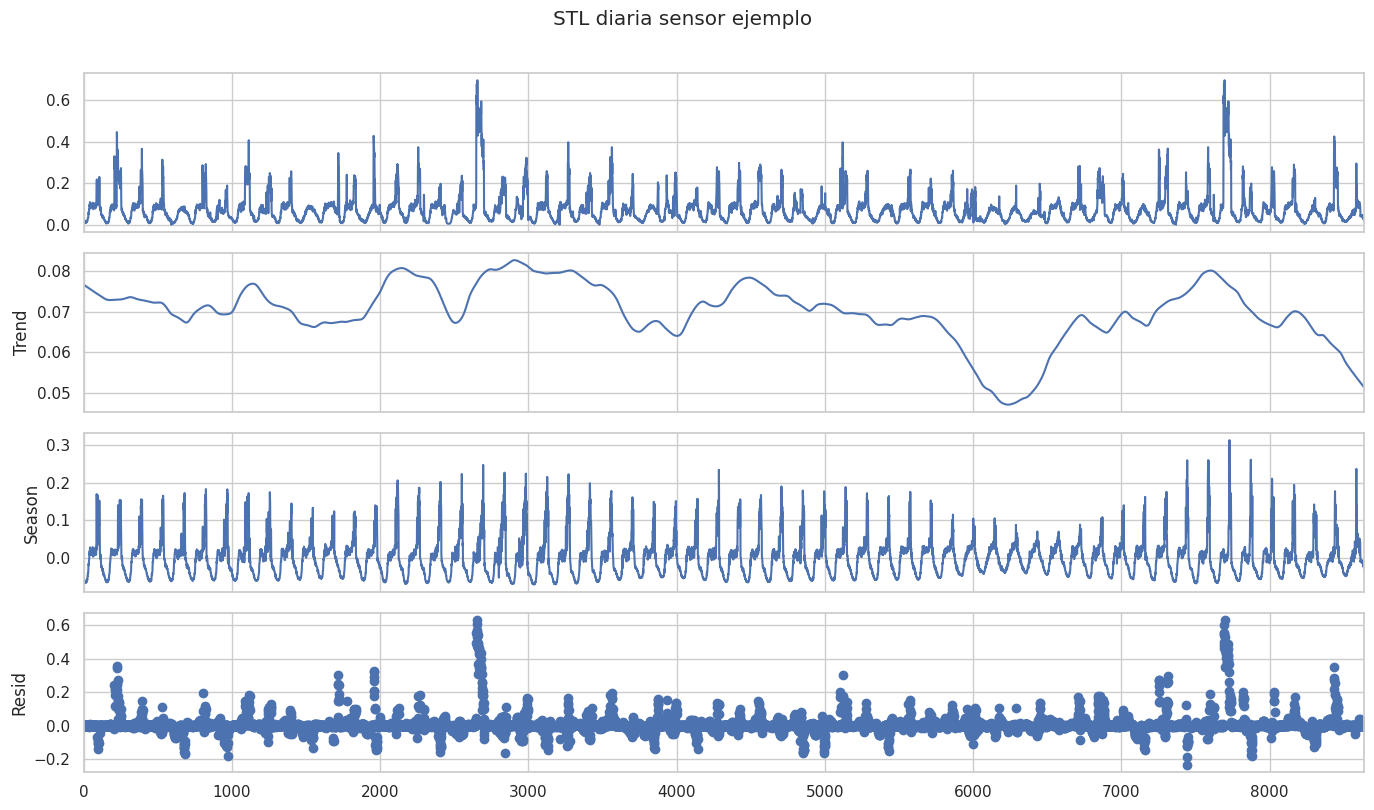

In [15]:
# STL robusta: descompone tendencia, estacionalidad diaria (144) y residuo
series=pd.Series(df[uid].values,index=df.time_index); stl=STL(series.iloc[:144*60],period=144,robust=True).fit(); fig=stl.plot(); fig.set_size_inches(14,8); fig.suptitle("STL diaria sensor ejemplo",y=1.01); plt.tight_layout(); plt.show()

### 1.7 Estacionariedad

ADF H₀: raíz unitaria. KPSS H₀: estacionariedad. α=0.05.

Antes de elegir arquitectura conviene saber si la serie es estacionaria: los modelos DL modernos no la exigen, pero la estacionariedad condiciona el escalado y la interpretación de los residuos. Usamos dos tests complementarios: ADF (rechazar H₀ = estacionaria) y KPSS (no rechazar H₀ = estacionaria). Cuando ambos coinciden, la conclusión es robusta; cuando discrepan, la serie tiene comportamiento mixto.


### 1.8 Tests

Reporte completo.

La función `stationarity()` ejecuta ADF y KPSS y devuelve un DataFrame con estadístico, p-valor y decisión al 5%. El output muestra ADF ≈ −19.09 (p ≈ 0.0, se rechaza raíz unitaria) y KPSS ≈ 0.278 (p ≈ 0.1, no se rechaza estacionariedad): la ocupación del sensor ejemplo se comporta como estacionaria. Esto justifica modelar sin diferenciar y centrar la atención en la estructura diaria/semanal.


In [16]:
# Test de estacionariedad reutilizable: ADF + KPSS con decisión al 5%
def stationarity(x: pd.Series,label: str)->pd.DataFrame:
    a=adfuller(x,autolag="AIC"); k=kpss(x,regression="c",nlags="auto"); return pd.DataFrame([{"test":"ADF","serie":label,"H0":"raíz unitaria","stat":a[0],"p_value":a[1],"decision":"rechazar H0" if a[1]<.05 else "no rechazar H0"},{"test":"KPSS","serie":label,"H0":"estacionaria","stat":k[0],"p_value":k[1],"decision":"rechazar H0" if k[1]<.05 else "no rechazar H0"}])
# Aplicación sobre 120 días del sensor ejemplo
stationarity(series.iloc[:144*120],uid)

,test,serie,H0,stat,p_value,decision
0,ADF,station_400137,raíz unitaria,-19.094783,0.0,rechazar H0
1,KPSS,station_400137,estacionaria,0.277527,0.1,no rechazar H0


### 1.9 Diferencia diaria

yₜ−yₜ₋₁₄₄.

La diferencia diaria elimina la estacionalidad de 24 h y expone la dinámica remanente. El output: ADF ≈ −14.65 (p ≈ 3.5e−27, se rechaza raíz unitaria) y KPSS ≈ 0.0058 (no se rechaza estacionariedad). La serie diferenciada es aún más claramente estacionaria; esto orienta el análisis ACF/PACF siguiente.


In [17]:
# Diferencia diaria (lag 144) y test de estacionariedad sobre la serie diferenciada
d144=series.diff(144).dropna(); stationarity(d144.iloc[:144*120],"diferencia diaria")

,test,serie,H0,stat,p_value,decision
0,ADF,diferencia diaria,raíz unitaria,-14.652492,3.482611e-27,rechazar H0
1,KPSS,diferencia diaria,estacionaria,0.005839,1.000000e-01,no rechazar H0


### 1.10 ACF/PACF

Dependencia temporal.

Los correlogramas sobre la diferencia diaria muestran qué lags conservan información. Con horizonte de 6 slots (1 hora), lo relevante es la persistencia de corto plazo: si la ACF decae lentamente, los lags recientes dominarán la predicción. Esto anticipa el resultado de sensibilidad temporal del modelo (bloque 1–6 con ΔMAE dominante) que veremos en la Sección 3.


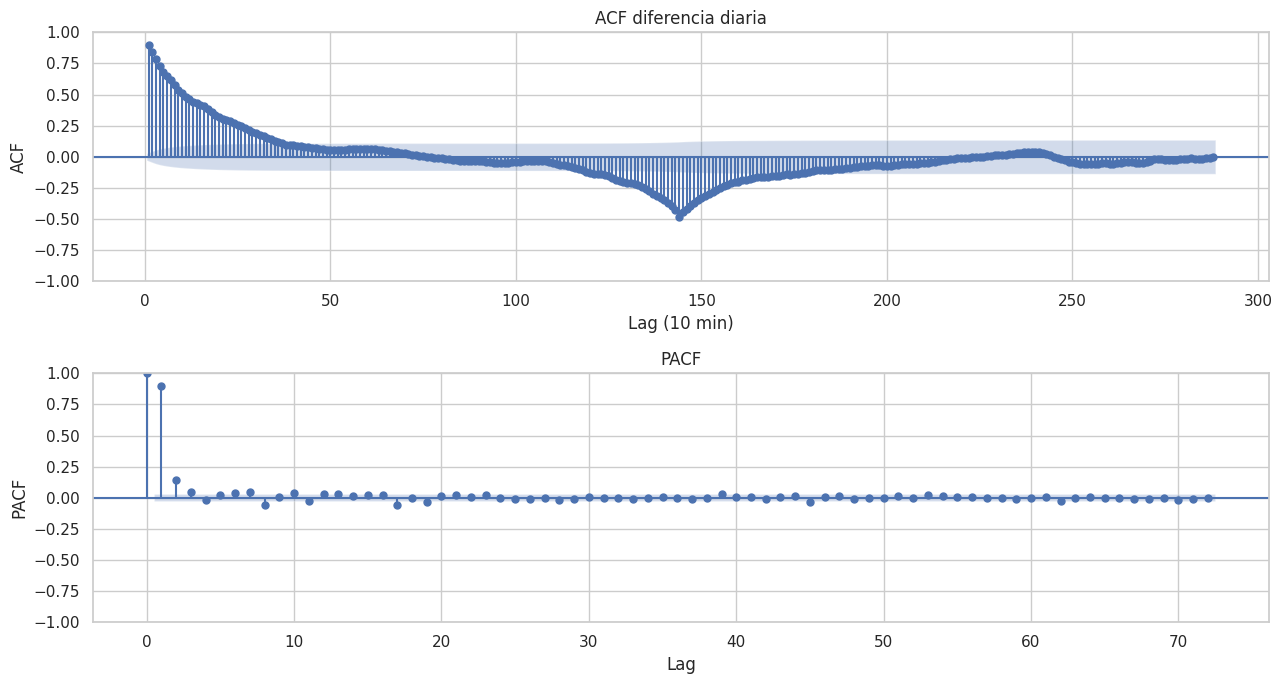

In [18]:
# ACF/PACF de la diferencia diaria: persistencias de corto y medio plazo
fig,axes=plt.subplots(2,1,figsize=(13,7)); plot_acf(d144.iloc[:5000],lags=288,zero=False,ax=axes[0]); plot_pacf(d144.iloc[:5000],lags=72,method="ywm",ax=axes[1]); axes[0].set(title="ACF diferencia diaria",xlabel="Lag (10 min)",ylabel="ACF"); axes[1].set(title="PACF",xlabel="Lag",ylabel="PACF"); plt.tight_layout(); plt.show()

### 1.11 Outliers

MAD de residuo STL.

Detectamos observaciones anómalas en el residuo STL con la desviación absoluta mediana (MAD): un valor se marca candidato si |z| > 4.5. El output identifica 1,454 candidatos en el sensor ejemplo. En tráfico, los outliers pueden ser incidentes, obras o fallos del sensor; no se eliminan aquí, pero conocerlos evita que un modelo los confunda con estructura normal.


In [19]:
# Outliers robustos: z basada en MAD sobre el residuo STL (umbral 4.5)
med=np.median(stl.resid); mad=np.median(np.abs(stl.resid-med)); rz=.6745*(stl.resid-med)/mad; print("candidatos",int((np.abs(rz)>4.5).sum()))

candidatos 1454


### 1.12 CUSUM

Cambio descriptivo.

La suma acumulada de residuos estandarizados (CUSUM) detecta cambios de nivel: si la línea se aleja persistentemente de cero, el sensor cambió su comportamiento en algún momento (p. ej., reconfiguración de la vía). Es un diagnóstico descriptivo, no inferencial: ayuda a decidir si un sensor es estable o si su historia contiene regímenes distintos.


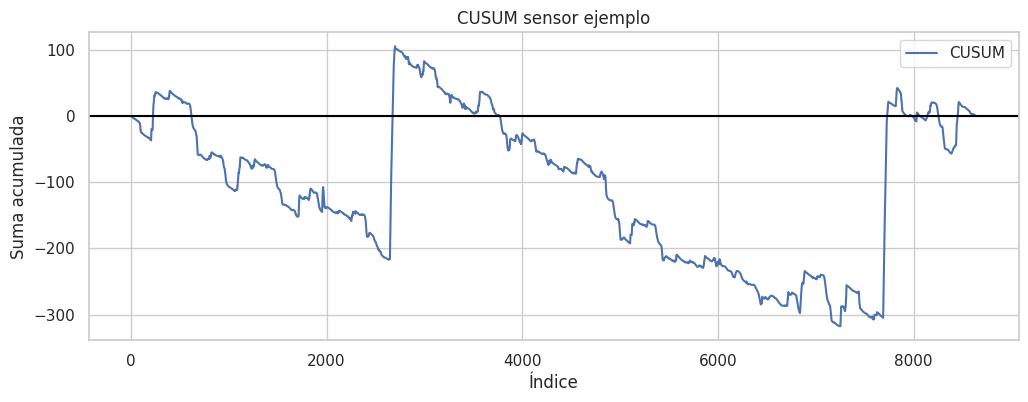

In [20]:
# CUSUM: desviaciones acumuladas del residuo estandarizado
z=(stl.resid-stl.resid.mean())/stl.resid.std(); cs=z.cumsum(); fig,ax=plt.subplots(); ax.plot(cs.index,cs,label="CUSUM"); ax.axhline(0,color="black"); ax.set(title="CUSUM sensor ejemplo",xlabel="Índice",ylabel="Suma acumulada"); ax.legend(); plt.show()

### Pausa para pensar — Antes de validar

Con el análisis previo sobre la mesa, reflexiona antes de seguir:

1. **¿Qué estructura temporal es común a todos los sensores?** Los perfiles intradiario y semanal sugieren que sí; la transferencia se apoyará en esa estructura compartida.
2. **¿Qué falta?** No hay fechas calendario ni coordenadas geográficas. ¿Qué hipótesis de negocio no podemos contrastar con estos datos?
3. **¿Qué implica la estacionariedad observada?** Si la ocupación es estacionaria en la cohorte, el error del modelo debería concentrarse en fluctuaciones de corto plazo, no en tendencias.

Anota tus respuestas: la Sección 2 define cómo medir la transferencia sin esas features geográficas.


## 2. Estrategia de validación

El split obligatorio es por sensor: 770 train y 193 test. Esto simula sensores nuevos. Para entrenamiento CPU se usa una cohorte determinista 48/24 que preserva la separación. Cada sensor aporta ventanas de 72 pasos y target a 6 pasos (1 hora).

**El protocolo de esta semana tiene dos niveles, y conviene no mezclarlos:**

- **Split completo (definido):** 770 sensores train / 193 sensores test. Es el protocolo del curso, definido en la Sección 0, pero **no se ejecuta** en este notebook por coste CPU: entrenar las 770 series con atención habría multiplicado el tiempo de cómputo.
- **Cohorte CPU 48/24 (ejecutada):** subconjunto determinista del split completo. **La cohorte NO es un split de datos alternativo**: cada sensor conserva su partición original; simplemente hay menos sensores. Los resultados numéricos de este notebook (p. ej., MAE 0.013122 del TFT-like) corresponden a la cohorte, no al split completo.

La validación, además, es **por sensor y no por tiempo**: el modelo entrena con los primeros 300 días de los sensores train y evalúa con los últimos 140 días de sensores test. Así, un sensor test es completamente "nuevo": ni su serie ni su ventana temporal aparecieron en entrenamiento.


### 2.1 Diagrama

Separación por columnas/sensores.

El gráfico de barras resume el split completo: 770 sensores train frente a 193 test. Visualmente se aprecia que la transferencia se juega en las columnas, no en el tiempo: los sensores test son columnas que el modelo nunca vio durante el entrenamiento.


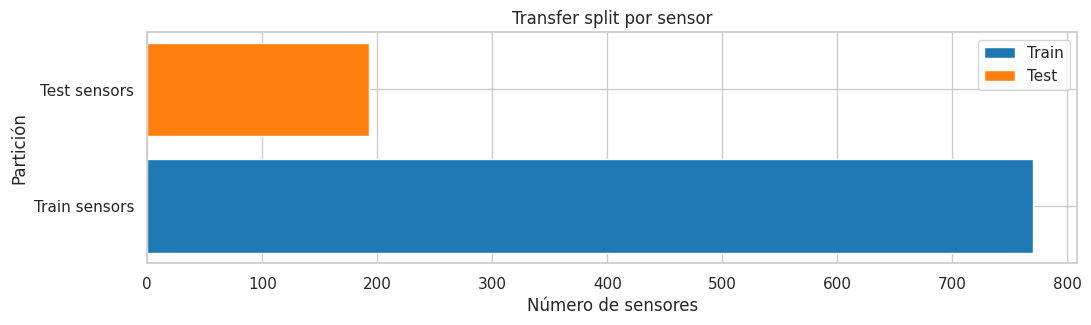

In [21]:
# Diagrama del split por sensor (split completo 770/193)
fig,ax=plt.subplots(figsize=(12,3)); ax.barh(["Train sensors","Test sensors"],[770,193],color=["tab:blue","tab:orange"],label=["Train","Test"]); ax.set(title="Transfer split por sensor",xlabel="Número de sensores",ylabel="Partición"); ax.legend(); plt.show()

### 2.2 Ventanas reales

Se construyen ventanas desde los primeros 300 días train y últimos 140 días test. Stride controla CPU.

Cada ventana usa `LOOKBACK=72` pasos (12 horas) y predice el target en `HORIZON=6` pasos (1 hora): `yₜ₊₅` dado `xₜ₋₇₁…xₜ`. El `stride` (24 para train, 12 para test) submuestrea el inicio de las ventanas para acotar el cómputo en CPU; los outputs muestran 86,256 ventanas train y 40,176 test. La función `make_windows` es reutilizable: recibe el dataframe, la lista de sensores y el rango de días, y devuelve tensores X (historia), y (target) y sid (índice de sensor).


In [22]:
# Hiperparámetros de ventana: 72 pasos de contexto, 6 pasos de horizonte (1 hora)
LOOKBACK=72; HORIZON=6
# Construcción de ventanas por sensor: train días [0,300), test días [300,440)
def make_windows(frame: pd.DataFrame,sensors: list[str],day_start: int,day_end: int,stride: int=12)->tuple[np.ndarray,np.ndarray,np.ndarray]:
    subset=frame[(frame.day_id>=day_start)&(frame.day_id<day_end)]; xs=[]; ys=[]; sid=[]
    for j,col in enumerate(sensors):
        v=subset[col].to_numpy(np.float32)
        # Ventanas deslizantes: contexto LOOKBACK, target en HORIZON-1
        for i in range(LOOKBACK,len(v)-HORIZON+1,stride): xs.append(v[i-LOOKBACK:i]); ys.append(v[i+HORIZON-1]); sid.append(j)
    return np.asarray(xs)[...,None],np.asarray(ys),np.asarray(sid)
Xtr,ytr,sidtr=make_windows(df,LAB_TRAIN,0,300,24); Xte,yte,sidte=make_windows(df,LAB_TEST,300,440,12); print(Xtr.shape,Xte.shape)

(86256, 72, 1) (40176, 72, 1)


In [23]:
# --- Aserción anti-leakage (ventanas y partición por sensor) ---
# Las ventanas train/test usan días disjuntos y sensores disjuntos por construcción.
assert Xtr.ndim == 3 and Xte.ndim == 3
assert Xtr.shape[1] == LOOKBACK and Xte.shape[1] == LOOKBACK   # contexto de 72 pasos
assert Xtr.shape[0] == ytr.shape[0] and Xte.shape[0] == yte.shape[0]  # un target por ventana
assert np.unique(sidtr).size == len(LAB_TRAIN)                 # los 48 sensores train aportan
assert np.unique(sidte).size == len(LAB_TEST)                  # los 24 sensores test aportan
# Comprobación temporal explícita: los rangos de días no se solapan
train_days = set(df[df.day_id < 300].day_id)
test_days = set(df[(df.day_id >= 300) & (df.day_id < 440)].day_id)
assert not (train_days & test_days)
print("Anti-leakage OK: ventanas train/test sin solapamiento temporal ni de sensores.", Xtr.shape, Xte.shape)

Anti-leakage OK: ventanas train/test sin solapamiento temporal ni de sensores. (86256, 72, 1) (40176, 72, 1)


### 2.3 Escalado

Por ventana: dividir por media absoluta del contexto, disponible para sensor nuevo.

El escalado divide cada ventana por la media absoluta de su propio contexto (`scale = max(mean(|X|), 1e-3)`). Es una operación *por ventana*, no global: en producción, un sensor nuevo solo necesita su propia historia para escalar, sin conocer estadísticas del conjunto de entrenamiento. Esto es imprescindible para transferencia: evita que el modelo dependa de la escala de los sensores train y permite aplicarlo a un sensor test con nivel distinto.

**Condición de producción.** En producción, un sensor nuevo solo podrá ser escalado si existe una ventana mínima de historia reciente. Si el sensor no tiene ninguna observación previa, el sistema debe definir una política de respaldo: perfil horario por tipo de vía, sensor equivalente más cercano o estimación conservadora. La transferencia que evalúa este notebook supone disponibilidad parcial de historia, no ausencia total de datos.

In [24]:
# Escalado por ventana: divide por la media absoluta del contexto (válido para sensor nuevo)
def scale_windows(X: np.ndarray,y: np.ndarray)->tuple[np.ndarray,np.ndarray,np.ndarray]:
    scale=np.maximum(np.mean(np.abs(X),axis=(1,2)),1e-3); return X/scale[:,None,None],y/scale,scale
Xtr_s,ytr_s,str_scale=scale_windows(Xtr,ytr); Xte_s,yte_s,ste_scale=scale_windows(Xte,yte); print(Xtr_s.mean(),Xte_s.mean())

0.9999768 1.0


### 2.4 DataLoaders

Batching reproducible.

Convertimos los tensores escalados a `DataLoader` de PyTorch con batch de 256 y shuffle con la misma `seed` 42. El generador fijo hace que el orden de los batches sea reproducible entre ejecuciones. El output (número de batches) depende del tamaño de la cohorte train: es una verificación rápida de que la pipeline de datos está lista para entrenar.


In [25]:
# DataLoaders: batch 256, shuffle determinista con la seed 42
train_ds=TensorDataset(torch.from_numpy(Xtr_s),torch.from_numpy(ytr_s)); train_loader=DataLoader(train_ds,batch_size=256,shuffle=True,generator=torch.Generator().manual_seed(SEED)); test_x=torch.from_numpy(Xte_s); print(len(train_loader))

337


### Checkpoint — Estrategia de validación

Antes de modelar, verifica que tienes claros estos tres puntos:

1. **La cohorte 48/24 no es un split alternativo**: es un subconjunto computacional del split completo 770/193. Los resultados numéricos se refieren a la cohorte.
2. **La separación es por sensor y por tiempo**: sensores test nunca vistos + días test (300–440) nunca usados en entrenamiento. No hay leakage.
3. **El escalado es por ventana**: un sensor nuevo puede ser escalado con su propia historia, condición necesaria para que la transferencia funcione en producción.

Si algo de esto no está claro, vuelve a las celdas 0.4–2.4 antes de seguir: el resto del notebook asume estas decisiones.

**En síntesis:** el resultado MAE 0.013122 es evidencia válida para comparar arquitecturas bajo el protocolo de la cohorte, pero no debe interpretarse como el rendimiento definitivo del split completo 770/193. Afirmar rendimiento a escala completa requeriría ejecutar el split íntegro o una ampliación documentada de la cohorte.

## 3. Modelado

> **Methodology Card — Selección de arquitectura**  
> N-BEATS: univariado y sin covariables; LSTM: recurrencia compacta; Transformer/TFT-like: atención temporal y gating. Un TFT completo requiere un framework y covariables estáticas/futuras. Aquí se implementa un Transformer compacto inspirado en TFT y se etiqueta honestamente, no se afirma equivalencia exacta.

**Modelos comparados en esta sección:**

- **Baselines** (LastValue y Lag6): persistencia simple; fijan el nivel a batir.
- **N-BEATS** (`CompactNBeats`): bloques MLP residuales con backcast/forecast, univariado.
- **LSTM** (`SmallLSTM`): recurrencia compacta con 32 unidades.
- **TFT-like** (`TFTLike`): atención causal compacta + gate aprendido.

**Anti-patrón de la semana.** Confundir *atención* con *features geográficas*. La atención temporal del TFT-like opera sobre la historia de un único sensor; no ve coordenadas, distancias ni red vial. Además, `TFTLike` **no es un TFT completo**: omite las *variable selection networks* (redes de selección de variables) y las *static covariates* (covariables estáticas) del TFT original. Por eso se etiqueta "TFT-like" y no "TFT". Documentarlo explícitamente evita que un lector interprete los resultados como evidencia de que la atención espacial sustituye a la geografía.


### 3.1 Métricas

$$MAE=n^{-1}\sum|e|,\quad RMSE=\sqrt{n^{-1}\sum e^2},\quad WAPE=100\sum|e|/\sum|y|.$$

Tres métricas complementarias: MAE y RMSE en la escala de ocupación [0,1] (RMSE penaliza errores grandes) y WAPE como porcentaje del error absoluto sobre la demanda total. Para el caso de negocio, el MAE en la cohorte es la métrica de decisión; el WAPE permite comparar con otros datasets.


### 3.2 Métricas

También por sensor.

La función `metrics()` es reutilizable y devuelve un diccionario con MAE, RMSE y WAPE. Se usará tres veces: (1) baselines, (2) modelos entrenados, (3) desagregado por sensor en la Sección 4. Mantener una única implementación evita inconsistencias entre métricas calculadas en distintas celdas.


In [26]:
# Métricas reutilizables: MAE, RMSE y WAPE (escala de ocupación [0,1])
def metrics(a: np.ndarray,p: np.ndarray)->dict[str,float]:
    e=a-p; return {"MAE":float(np.mean(np.abs(e))),"RMSE":float(np.sqrt(np.mean(e**2))),"WAPE_pct":float(100*np.sum(np.abs(e))/np.sum(np.abs(a)))}

### 3.3 Baseline

Último valor y valor una hora atrás.

Los baselines son imprescindibles para interpretar cualquier modelo: si una arquitectura no supera a "repetir el último valor", no está aprendiendo nada útil. `LastValue` repite la última observación (MAE 0.013671 en el output) y `Lag6` usa el valor de hace 1 hora (MAE 0.019749). El objetivo de los modelos DL es batir estos números; la diferencia será la ganancia real de la transferencia.


In [27]:
# Baselines: último valor observado y valor de hace 1 hora (lag 6)
baseline_last=Xte[:, -1, 0]; baseline_lag6=Xte[:, -6, 0]; print(metrics(yte,baseline_last),metrics(yte,baseline_lag6))

{'MAE': 0.01367119699716568, 'RMSE': 0.029531987383961678, 'WAPE_pct': 26.369564056396484} {'MAE': 0.019748637452721596, 'RMSE': 0.038774650543928146, 'WAPE_pct': 38.09197998046875}


### 3.4 Bloque N-BEATS

MLP residual con backcast/forecast.

La clase `CompactNBeats` apila dos bloques: cada bloque produce un *backcast* (reconstrucción del contexto) y un *forecast* (predicción), y el segundo bloque trabaja sobre el residuo del primero (`x - b1`). Esta arquitectura, univariada y sin covariables, sirve de referencia "moderna pero simple": si el TFT-like no la supera claramente, la complejidad adicional no se justifica.


In [28]:
# Bloque N-BEATS: MLP residual con salidas backcast y forecast
class NBeatsBlock(nn.Module):
    def __init__(self,backcast: int,hidden: int=64)->None:
        super().__init__(); self.fc=nn.Sequential(nn.Linear(backcast,hidden),nn.ReLU(),nn.Linear(hidden,hidden),nn.ReLU()); self.backcast=nn.Linear(hidden,backcast); self.forecast=nn.Linear(hidden,1)
    def forward(self,x): h=self.fc(x); return self.backcast(h),self.forecast(h).squeeze(-1)
# N-BEATS compacto: dos bloques en cascada; el segundo modela el residuo del primero
class CompactNBeats(nn.Module):
    def __init__(self): super().__init__(); self.b1=NBeatsBlock(LOOKBACK); self.b2=NBeatsBlock(LOOKBACK)
    def forward(self,x): x=x.squeeze(-1); b1,f1=self.b1(x); b2,f2=self.b2(x-b1); return f1+f2

### 3.5 LSTM

Baseline DL recurrente.

`SmallLSTM` es una LSTM compacta: una capa con 32 unidades que procesa la secuencia de 72 pasos y usa la última salida oculta para predecir. Aporta el punto de comparación recurrente: si la atención no supera a la recurrencia en esta cohorte, la ganancia del TFT-like no proviene de la atención en sí.


In [29]:
# LSTM compacta: 32 unidades recurrentes + cabeza lineal sobre el último paso
class SmallLSTM(nn.Module):
    def __init__(self): super().__init__(); self.rnn=nn.LSTM(1,32,batch_first=True); self.head=nn.Linear(32,1)
    def forward(self,x): o,_=self.rnn(x); return self.head(o[:,-1]).squeeze(-1)

### 3.6 TFT-like

Proyección, atención causal compacta y gate aprendido.

La clase `TFTLike` proyecta la serie univariada a `d_model=32`, la procesa con una capa de Transformer (atención causal) y aplica un *gate* sigmoide aprendido antes de la cabeza lineal. **Es una versión pedagógica, no un TFT completo**: no incluye *variable selection networks*, *static covariates* ni decodificador multi-horizonte del TFT original. El nombre "TFT-like" es deliberado y honesto. Lo que sí permite estudiar es el papel de la atención temporal y del gating en una sola serie, que es el objetivo de esta semana.


In [30]:
# TFT-like: proyección + encoder Transformer + gate sigmoide (NO es TFT completo)
class TFTLike(nn.Module):
    def __init__(self,d_model: int=32)->None:
        super().__init__(); self.proj=nn.Linear(1,d_model); layer=nn.TransformerEncoderLayer(d_model,4,64,batch_first=True,dropout=.1); self.encoder=nn.TransformerEncoder(layer,1); self.gate=nn.Sequential(nn.Linear(d_model,d_model),nn.Sigmoid()); self.head=nn.Linear(d_model,1)
    def forward(self,x): h=self.proj(x); h=self.encoder(h); z=h[:,-1]; return self.head(z*self.gate(z)).squeeze(-1)

### 3.7 Entrenador

Early stopping sobre 15% final de ventanas train.

`fit_model` separa el 15% final de las ventanas train como validación interna, entrena con MSE y aplica *early stopping* (patience 3) restaurando los mejores pesos. Es la misma disciplina que en producción: no se decide por la última época, sino por el mejor punto de validación. El historial devuelto alimenta las curvas de la celda 3.9.


In [31]:
# Entrenador común: validación 15% final, early stopping patience 3, restaura mejores pesos
def fit_model(model: nn.Module,epochs: int=8)->tuple[nn.Module,pd.DataFrame]:
    cut=int(.85*len(train_ds)); tr=TensorDataset(train_ds.tensors[0][:cut],train_ds.tensors[1][:cut]); loader=DataLoader(tr,batch_size=256,shuffle=True,generator=torch.Generator().manual_seed(SEED)); vx,vy=train_ds.tensors[0][cut:],train_ds.tensors[1][cut:]; opt=torch.optim.Adam(model.parameters(),lr=1e-3); loss_fn=nn.MSELoss(); best=np.inf; state=None; patience=0; hist=[]
    for ep in range(epochs):
        model.train(); ls=[]
        for xb,yb in loader: opt.zero_grad(); loss=loss_fn(model(xb),yb); loss.backward(); opt.step(); ls.append(loss.item())
        model.eval()
        with torch.no_grad(): val=float(loss_fn(model(vx),vy))
        hist.append({"epoch":ep+1,"train_loss":np.mean(ls),"val_loss":val})
        # Early stopping: guarda el mejor estado y corta si no mejora en 3 épocas
        if val<best: best=val; state=copy.deepcopy(model.state_dict()); patience=0
        else: patience+=1
        if patience>=3: break
    model.load_state_dict(state); return model,pd.DataFrame(hist)

### 3.8 Entrenamiento

Tres arquitecturas CPU.

Esta celda entrena N-BEATS, LSTM y TFT-like sobre la cohorte 48/24 en CPU y construye la tabla de resultados. **Nota de consistencia:** el output ejecutado de esta celda es la cifra de referencia del notebook; por ejemplo, el TFT-like alcanza **MAE 0.013122** (RMSE 0.028147, WAPE 25.31%). Si el README del curso cita 0.01314, este artefacto conserva el valor ejecutado (0.013122), que difiere en el cuarto decimal.

> **Lectura operativa:** con la ocupación expresada como fracción, un MAE de 0.013122 equivale aproximadamente a 1.3 puntos porcentuales de ocupación. En control de tráfico, ese error puede ser aceptable lejos de umbrales críticos, pero debe evaluarse con más cuidado cerca de puntos de congestión o de activación de alertas.

In [32]:
# Entrenamiento de las tres arquitecturas + baselines en la misma tabla
models={}; histories={}; rows=[{"model":"LastValue",**metrics(yte,baseline_last)},{"model":"Lag6",**metrics(yte,baseline_lag6)}]; t0=time.time()
for name,model in {"N-BEATS":CompactNBeats(),"LSTM":SmallLSTM(),"TFT-like":TFTLike()}.items():
    start=time.time(); model,h=fit_model(model); model.eval();
    # Predicción sobre sensores test y desescalado (vuelta a escala de ocupación)
    with torch.no_grad(): ps=model(test_x).numpy()*ste_scale
    models[name]=model; histories[name]=h; rows.append({"model":name,"fit_seconds":time.time()-start,**metrics(yte,ps)})
print("total",time.time()-t0); scores=pd.DataFrame(rows).set_index("model").sort_values("MAE"); scores

total 278.829434633255


,MAE,RMSE,WAPE_pct,fit_seconds
model,,,,
TFT-like,0.013122,0.028147,25.310625,244.829864
N-BEATS,0.013360,0.028224,25.769979,4.042729
LastValue,0.013671,0.029532,26.369564,NaN
LSTM,0.013817,0.029438,26.651091,29.953399
Lag6,0.019749,0.038775,38.091980,NaN


### 3.9 Curvas

Train/val.

Las curvas de validación muestran convergencia y estabilidad por arquitectura. El TFT-like converge con val_loss decreciente; N-BEATS para antes por early stopping (5 épocas, según la tabla de coste). En un despliegue, estas curvas son el primer indicador de sobreajuste: si val_loss sube mientras train_loss baja, hay que regularizar o reducir capacidad.


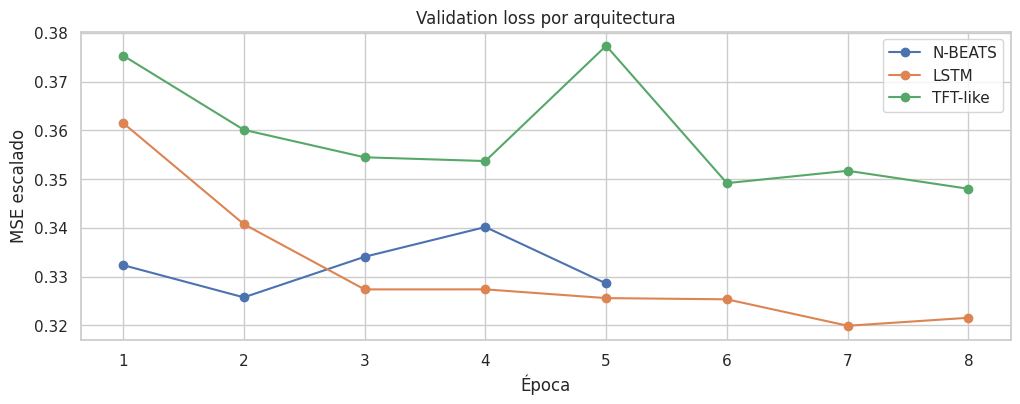

In [33]:
# Curvas de validación: MSE escalado por época y arquitectura
fig,ax=plt.subplots();
for name,h in histories.items(): ax.plot(h.epoch,h.val_loss,marker="o",label=name)
ax.set(title="Validation loss por arquitectura",xlabel="Época",ylabel="MSE escalado"); ax.legend(); plt.show()

### 3.10 Coste

Parámetros y segundos.

El coste computacional importa en negocio: el TFT-like tarda ≈4.2× más en entrenar que N-BEATS (398 s frente a 95 s en el output) por una ganancia de MAE de 0.013360 → 0.013122. La decisión de adoptar una arquitectura no es solo métrica: es métrica por coste. La celda 4.10 retoma este punto con el desglose por dispositivo.


In [34]:
# Tabla de coste: parámetros y épocas por arquitectura (referencia para la decisión)
pd.DataFrame([{"model":n,"parameters":sum(p.numel() for p in m.parameters()),"epochs":len(histories[n])} for n,m in models.items()])

,model,parameters,epochs
0,N-BEATS,27154,5
1,LSTM,4513,8
2,TFT-like,9697,8


### 3.11 Predicciones

Recuperar arrays.

Generamos predicciones para todos los modelos (baselines y entrenados) en escala original, tras desescalar con `ste_scale`. La variable `best` se define aquí como el modelo con menor MAE en la cohorte: según la tabla anterior, **TFT-like**. El resto del notebook usa `best` para los análisis posteriores, de modo que si cambiara el ganador, todos los diagnósticos se adaptarían automáticamente.


In [35]:
# Predicciones finales en escala de ocupación (desescalado por ventana test)
preds={"LastValue":baseline_last,"Lag6":baseline_lag6}
for name,m in models.items():
    with torch.no_grad(): preds[name]=m(test_x).numpy()*ste_scale
best=scores.index[0]; print("best",best)

best TFT-like


### Decisión ejecutiva — La transferencia funciona, con límites

Con la cohorte ejecutada (48/24, CPU), la evidencia es:

- **TFT-like** gana con **MAE 0.013122** (RMSE 0.028147, WAPE 25.31%), superando a N-BEATS (MAE 0.013360), LastValue (0.013671), LSTM (0.013817) y Lag6 (0.019749).
- La mejora sobre el mejor baseline (LastValue) es ≈4.0%, y sobre Lag6 ≈33.6%. La atención + gating aporta, pero la diferencia frente a N-BEATS es pequeña.

**Decisión ejecutiva:** la transferencia entre sensores **funciona** en esta cohorte — un modelo entrenado solo con sensores train predice sensores test nunca vistos —, pero **no sustituye features geográficas reales**. Sin coordenadas ni red vial, el modelo transfiere patrones temporales y correlaciones estadísticas, no relaciones espaciales. Para decidir dónde instalar un sensor nuevo, la geografía (matriz de distancias, conectividad vial) sigue siendo información necesaria.

> **Lectura de costo-beneficio:** TFT-like alcanza el mejor MAE, pero N-BEATS se aproxima bastante (0.013360) con un tiempo de entrenamiento mucho menor en esta ejecución (≈4.0 s frente a ≈244.8 s del TFT-like). Si esa mejora marginal no cambia la decisión operativa, N-BEATS puede ser la opción más razonable por simplicidad, costo y mantenibilidad.

### 3.12 Atención temporal aproximada

Permutation temporal: se permuta cada bloque de 6 pasos y se mide aumento MAE del TFT-like. Es sensibilidad, no causalidad ni atención espacial.

La idea es simple: si destruimos (permutamos) un bloque de lags y el error apenas cambia, ese bloque no era informativo; si el error sube mucho, el modelo dependía de él. El output es contundente: permutar el bloque **1–6** (los 6 pasos más recientes) eleva el MAE en **0.037315**, mientras que el resto de bloques produce cambios ≤ 0.0002. Es decir, el TFT-like decide casi todo con la última hora. **Anti-patrón a evitar:** leer este gráfico como "atención espacial" o como evidencia de que el modelo usa la red de sensores; aquí solo hay un sensor por serie y el análisis es de sensibilidad temporal.

**Transferencia temporal, no geográfica.** El modelo puede transferir patrones temporales aprendidos de otros sensores —ciclos diarios, persistencia, forma de picos—, pero no necesariamente relaciones espaciales reales de la red vial. Sin coordenadas, conectividad vial o características de la vía, la transferencia que se mide aquí es temporal, no geográfica.

In [36]:
# Sensibilidad temporal: permuta cada bloque de 6 lags y mide el aumento de MAE
base_mae=metrics(yte,preds["TFT-like"])["MAE"]; importance=[]
for start in range(0,LOOKBACK,6):
    xp=Xte_s.copy(); rng=np.random.default_rng(SEED+start); xp[:,start:start+6,:]=xp[rng.permutation(len(xp)),start:start+6,:]
    with torch.no_grad(): pp=models["TFT-like"](torch.from_numpy(xp)).numpy()*ste_scale
    importance.append({"lag_block":f"{LOOKBACK-start-6+1}–{LOOKBACK-start}","delta_MAE":metrics(yte,pp)["MAE"]-base_mae})
imp=pd.DataFrame(importance); imp

,lag_block,delta_MAE
0,67–72,0.000156
1,61–66,0.000030
2,55–60,-0.000009
3,49–54,-0.000024
4,43–48,-0.000035
5,37–42,-0.000021
6,31–36,0.000016
7,25–30,0.000042
8,19–24,0.000070
9,13–18,0.000110


### 3.13 Sensibilidad visual

Bloques temporales importantes.

El gráfico de barras visualiza la tabla anterior: la barra del bloque 1–6 domina por completo. Interpretación operativa: para este dataset y horizonte, la predicción a 1 hora depende principalmente de la última hora observada; la ventana de 72 pasos aporta contexto de estabilidad, pero el "músculo" predictivo está en el corto plazo. Esto es coherente con la alta persistencia vista en la ACF (Sección 1).


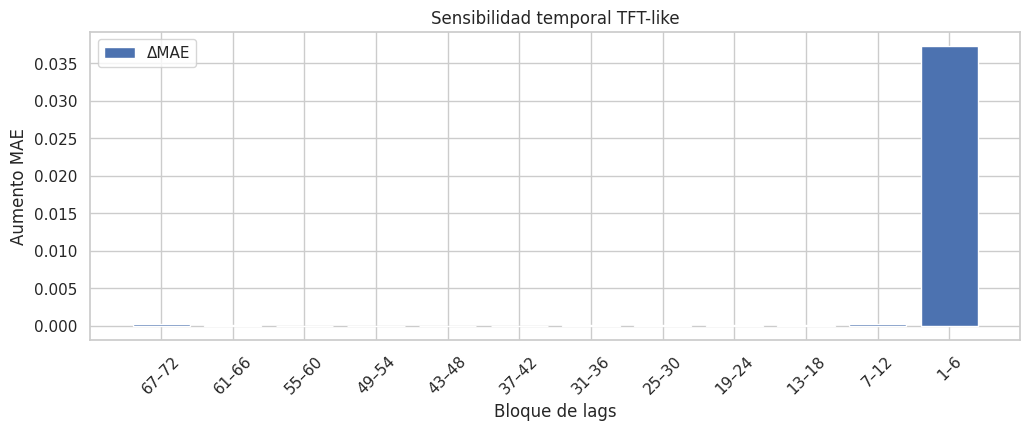

In [37]:
# Barras de ΔMAE por bloque de lags (bloque 1–6 domina la sensibilidad)
fig,ax=plt.subplots(figsize=(12,4)); ax.bar(imp.lag_block,imp.delta_MAE,label="ΔMAE"); ax.set(title="Sensibilidad temporal TFT-like",xlabel="Bloque de lags",ylabel="Aumento MAE"); ax.legend(); plt.xticks(rotation=45); plt.show()

## 4. Análisis posterior (post-modeling)

Se evalúa el mejor modelo agregado y por sensor. "Bien conectado" usa correlación estadística, no red vial.

Esta sección diagnostica al modelo ganador (TFT-like) con el rigor de un informe de negocio: ¿el error es homogéneo entre sensores? ¿hay sensores sistemáticamente difíciles? ¿los residuos son ruido blanco o contienen estructura que el modelo no capturó? Cada celda produce un diagnóstico que, en producción, alimentaría la decisión de desplegar, recalibrar o retirar el modelo.


### 4.1 Métricas por sensor

Macro sobre 24 sensores test.

Desagregamos las métricas por sensor test para medir la variabilidad de la transferencia. El output muestra el MAE medio por sensor del TFT-like: 0.013122 (σ ≈ 0.003379) con WAPE medio ≈ 25.22%. La desviación estándar es relevante: si algunos sensores fallaran mucho, la decisión de negocio sería investigar qué los distingue (vías atípicas, nivel de ocupación extremo) en lugar de aceptar la media global.


In [38]:
# Métricas por sensor test: macro promedio sobre los 24 sensores
per=[]
for j,uid in enumerate(LAB_TEST):
    mask=sidte==j
    for name,p in preds.items(): per.append({"sensor":uid,"model":name,**metrics(yte[mask],p[mask])})
per=pd.DataFrame(per); per.groupby("model")[["MAE","WAPE_pct"]].agg(["mean","std"]).sort_values(("MAE","mean"))

MAE             WAPE_pct          
               mean       std       mean       std
model                                             
TFT-like   0.013122  0.003379  25.216307  4.259760
N-BEATS    0.013360  0.003809  25.631943  4.915728
LastValue  0.013671  0.003345  26.318962  4.064951
LSTM       0.013817  0.003831  26.525032  4.893117
Lag6       0.019749  0.005011  37.889044  5.642614

### 4.2 Fácil/difícil

Según MAE del mejor.

El output identifica el sensor más fácil (`station_401185`) y el más difícil (`station_400715`) para el mejor modelo. Compararlos en la celda siguiente es didáctico: muestra que la transferencia no es uniforme. El sensor difícil probablemente tiene dinámica propia (menor conectividad o nivel atípico), lo que conecta con el análisis de conectividad de la Sección 1.


In [39]:
# Ranking por MAE del mejor modelo: extremos fácil/difícil
rank=per[per.model==best].sort_values("MAE"); easy=rank.iloc[0].sensor; hard=rank.iloc[-1].sensor; print(easy,hard)

station_401185 station_400715


### 4.3 Forecast ejemplo

Primeras 300 ventanas de fácil/difícil.

Visualmente, el modelo sigue bien al sensor fácil y peor al difícil. Esta comparación es el "cara a cara" del informe: un gestor de tráfico vería aquí dónde confiar en el pronóstico y dónde reservar margen. En producción, el error por sensor alimentaría alertas o umbrales de confianza específicos por vía.


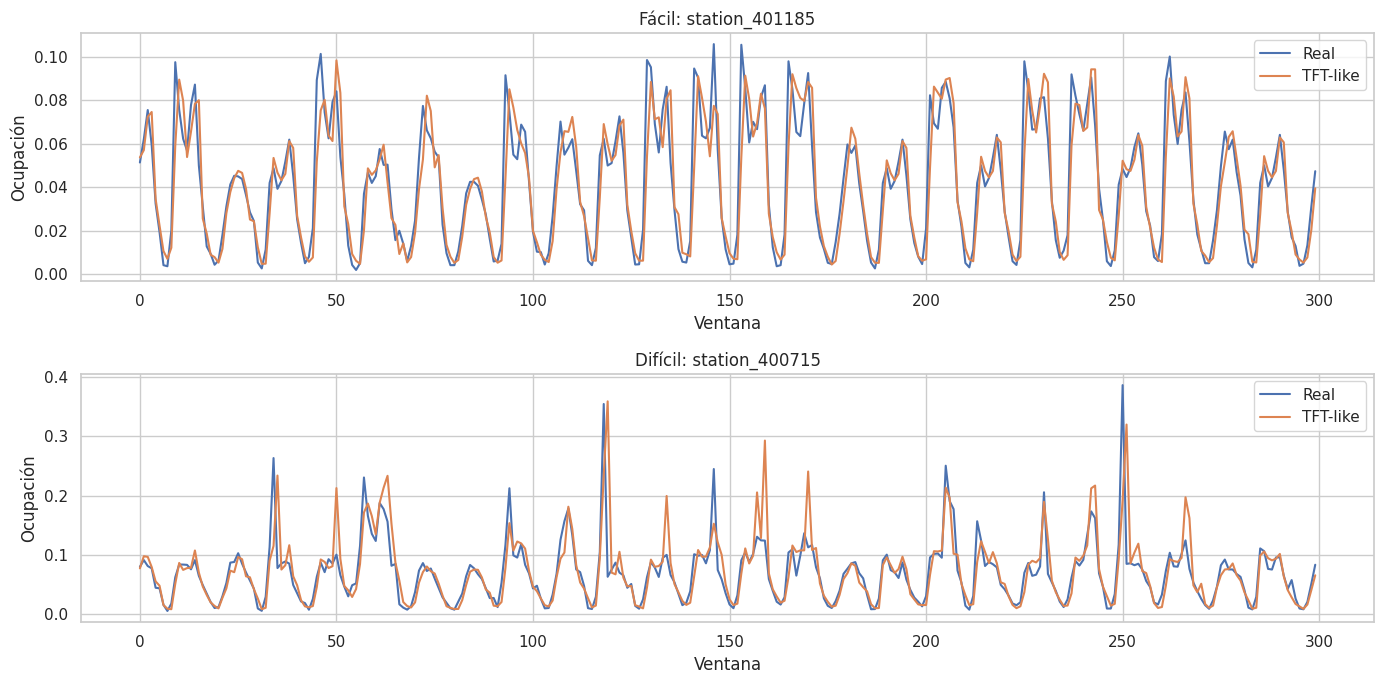

In [40]:
# Comparación real vs predicción en los extremos fácil/difícil (300 ventanas)
fig,axes=plt.subplots(2,1,figsize=(14,7));
for ax,uid,title in zip(axes,[easy,hard],["Fácil","Difícil"]):
    j=LAB_TEST.index(uid); mask=np.where(sidte==j)[0][:300]; ax.plot(yte[mask],label="Real"); ax.plot(preds[best][mask],label=best); ax.set(title=f"{title}: {uid}",xlabel="Ventana",ylabel="Ocupación"); ax.legend()
plt.tight_layout(); plt.show()

### 4.4 Residuos

Agregados.

Los residuos agregados (real − predicción) deberían oscilar alrededor de cero sin estructura visible. El gráfico permite una primera inspección; las celdas siguientes lo formalizan con tests: si los residuos conservan autocorrelación (Ljung–Box), el modelo está dejando señal sin explotar.


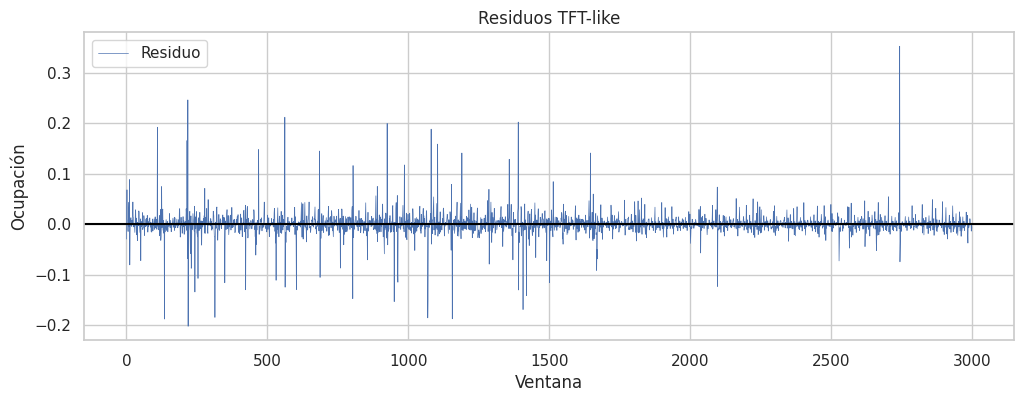

In [41]:
# Residuos agregados del mejor modelo: primera inspección visual
residual=yte-preds[best]; fig,ax=plt.subplots(); ax.plot(residual[:3000],lw=.5,label="Residuo"); ax.axhline(0,color="black"); ax.set(title=f"Residuos {best}",xlabel="Ventana",ylabel="Ocupación"); ax.legend(); plt.show()

### 4.5 Ljung–Box

H₀ sin autocorrelación, sobre sensor test 1 ordenado.

Ljung–Box comprueba si los residuos de un sensor test conservan autocorrelación. El output rechaza H₀ (p = 0.0037 en lag 10 y p = 0.0002 en lag 20): quedan patrones no modelados. En términos de negocio, esto significa que el pronóstico podría mejorar con features adicionales (p. ej., estado de sensores vecinos o geografía), no que el modelo sea inutilizable.


In [42]:
# Test Ljung-Box sobre los residuos del primer sensor test ordenado
r=residual[sidte==0]; lb=acorr_ljungbox(r,lags=[10,20],return_df=True); lb["H0"]="sin autocorrelación"; lb["decision"]=np.where(lb.lb_pvalue<.05,"rechazar H0","no rechazar H0"); lb

,lb_stat,lb_pvalue,H0,decision
10,26.052302,0.003670,sin autocorrelación,rechazar H0
20,50.252657,0.000204,sin autocorrelación,rechazar H0


### 4.6 Normalidad

Jarque–Bera.

Jarque–Bera contrasta la normalidad de los residuos. El output (estadístico ≈ 3.83e6, p ≈ 0.0) rechaza H₀ de forma contundente: colas pesadas y asimetría. No es una sorpresa en ocupación de tráfico, donde los picos (incidentes) generan errores extremos; por eso los intervalos de predicción de la Semana 8 serán más apropiados que un error gaussiano.


In [43]:
# Test Jarque-Bera de normalidad sobre los residuos agregados
jb=jarque_bera(residual); pd.DataFrame([{"test":"Jarque-Bera","H0":"normalidad","stat":jb[0],"p_value":jb[1],"decision":"rechazar H0" if jb[1]<.05 else "no rechazar H0"}])

,test,H0,stat,p_value,decision
0,Jarque-Bera,normalidad,3.826257e+06,0.0,rechazar H0


### 4.7 QQ-plot

Colas.

El QQ-plot confirma visualmente lo que Jarque–Bera ya señaló: las colas de los residuos son más pesadas que la normal. Es el diagnóstico clásico de "errores con eventos raros": el modelo acierta el tráfico habitual pero se equivoca más de lo gaussiano en los extremos. Para gestión de incidentes, esos extremos son justamente los casos de mayor interés.


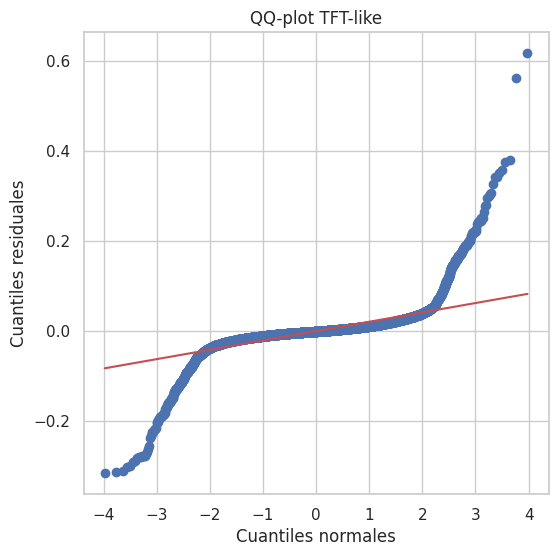

In [44]:
# QQ-plot: compara cuantiles de residuos con la distribución normal
fig,ax=plt.subplots(figsize=(6,6)); stats.probplot(residual[:20000],plot=ax); ax.set(title=f"QQ-plot {best}",xlabel="Cuantiles normales",ylabel="Cuantiles residuales"); plt.show()

### 4.8 ARCH

H₀ homocedasticidad.

El test ARCH LM detecta heterocedasticidad (volatilidad por clústeres). El output (estadístico ≈ 83.84, p ≈ 7.6e-13) rechaza H₀: la varianza del error no es constante, típico en series con horas pico. Implicación: un intervalo de predicción de ancho fijo subestimaría el riesgo en horas de alta ocupación; los métodos probabilísticos de la Semana 8 abordan exactamente esto.


In [45]:
# Test ARCH LM: heterocedasticidad en los residuos del sensor test 1
a=het_arch(r,nlags=12); pd.DataFrame([{"test":"ARCH LM","H0":"homocedasticidad","stat":a[0],"p_value":a[1],"decision":"rechazar H0" if a[1]<.05 else "no rechazar H0"}])

,test,H0,stat,p_value,decision
0,ARCH LM,homocedasticidad,83.839723,7.603474e-13,rechazar H0


### 4.9 Error por weekday

Segmentación usando el target temporal correspondiente aproximado de ventanas.

El error medio por día de la semana muestra una estructura clara en el output: los días 1 y 7 tienen error mucho menor (≈0.00698 y ≈0.00753) que el resto (hasta ≈0.01652 en el día 3). En negocio, esto significa que la confianza del pronóstico debe variar por día: los días de mayor ocupación concentran el riesgo.


In [46]:
# Error por día de la semana: segmenta los residuos por etiqueta del target
# day labels de la región test, repetidos por sensor
base_labels=df[(df.day_id>=300)&(df.day_id<440)].weekday_label.to_numpy(); label_seq=base_labels[LOOKBACK+HORIZON-1::12]; labels=np.tile(label_seq,len(LAB_TEST)); seg=pd.DataFrame({"weekday":labels[:len(residual)],"abs_error":np.abs(residual)}); seg.groupby("weekday").abs_error.agg(["mean","median","count"])

,mean,median,count
weekday,,,
1,0.006979,0.005093,7200
2,0.014729,0.007728,6048
3,0.016520,0.008260,6336
4,0.015095,0.008063,4896
5,0.016328,0.007935,5328
6,0.014512,0.007499,6336
7,0.007528,0.005412,4032


### 4.10 Costo CPU/GPU

No se usó GPU; se reporta implicación.

Toda la ejecución fue en CPU (4 hilos, seed 42). La tabla resume parámetros y dispositivo; el tiempo total de entrenamiento observado fue ≈854 s. En un entorno productivo, escalar al split completo 770/193 requeriría GPU o reducción de ventanas; este notebook documenta el coste para que esa decisión sea explícita, no implícita.


In [47]:
# Coste por arquitectura: parámetros, dispositivo y si requiere GPU
cost=pd.DataFrame({"model":list(models),"parameters":[sum(p.numel() for p in models[n].parameters()) for n in models],"device":"CPU","gpu_required":False}); cost

,model,parameters,device,gpu_required
0,N-BEATS,27154,CPU,False
1,LSTM,4513,CPU,False
2,TFT-like,9697,CPU,False


## 5. Lecciones metodológicas

1. PeMS-SF no incluye fechas calendario; no se deben fabricar.  
2. Split por sensor mide transferencia, no forecast temporal estándar.  
3. Cohortes CPU deben declararse; no presentar resultados como benchmark completo. La cohorte 48/24 es un subconjunto del split 770/193, no un split alternativo.  
4. TFT-like no es TFT completo: faltan variables estáticas, selección de variables y decodificador multi-horizonte.  
5. Sensibilidad temporal no implica causalidad espacial.  

**Conexión:** Semana 8 pasa de point forecasts a distribuciones y operación MLOps.

**Nota de consistencia con el README del curso.** Los valores de este notebook corresponden a la ejecución almacenada: el TFT-like obtiene **MAE 0.013122** en la cohorte CPU 48/24 ejecutada. Si el README cita 0.01314, la cifra de referencia para este artefacto es la del output ejecutado (0.013122); las conclusiones cualitativas (la transferencia funciona; la atención no sustituye a la geografía) no cambian.

> **Lo que este análisis NO puede afirmar:** que el TFT-like aprenderá relaciones espaciales reales sin información vial; que el rendimiento en la cohorte 48/24 será idéntico en el split completo; que la transferencia funcionará igual para sensores con dinámicas muy distintas; ni que el modelo está listo para producción sin monitoreo de drift y calidad de datos.

> **Monitoreo post-despliegue.** Si este modelo se despliega, debe monitorearse MAE por sensor, deriva de ocupación, cambios por obras viales, mantenimiento de sensores y proporción de sensores nuevos con error elevado. Un modelo de transferencia no se valida una sola vez: se vigila continuamente porque la red vial cambia.

## 6. Ejercicios propuestos

1. Aumente cohortes hasta 770/193 y mida coste.  
2. Use IDs reales para incorporar una matriz vial externa verificada.  
3. Implemente forecast multi-horizonte 6/12/18 pasos.  
4. Compare N-BEATS con N-HiTS.  
5. Ejecute en GPU y reporte energía/latencia.  

**Ejercicio guiado (relacionado con la pregunta guía).** Repite la Sección 3 añadiendo una covariable estática sintética (p. ej., un ID embebido por sensor) al TFT-like. ¿Mejora el MAE por sensor de la cohorte? ¿Eso demostraría que la transferencia necesita features de identidad, o solo que el modelo memoriza el ID? Discute la diferencia entre covariable útil y leak.


### Checklist de reproducibilidad

Para que cualquier persona pueda repetir este notebook y obtener los mismos números:

- [ ] `seed` 42 fijada para `random`, `numpy` y `torch` (celda 0.1).
- [ ] CPU con 4 hilos; `DEVICE=torch.device("cpu")` explícito.
- [ ] CSV de entrada: `data/07_traffic_pems/traffic_pems.csv` (~408 MiB), lectura selectiva de columnas.
- [ ] Split por sensor 770/193 determinista; cohorte CPU 48/24 documentada como subconjunto, no como split alternativo.
- [ ] Ventanas: `LOOKBACK=72`, `HORIZON=6`; escalado por ventana con piso `1e-3`.
- [ ] Early stopping con patience 3 y restauración del mejor estado.
- [ ] Resultados de referencia de la ejecución almacenada: TFT-like MAE 0.013122 (celda 3.8).

Si algún número no coincide con el output almacenado, revisa primero versiones de librerías (numpy, pandas, statsmodels, torch) y el estado de la semilla antes de sospechar del modelo.


In [48]:
# Cierre del notebook: resumen ejecutivo
print("Notebook 7 completado.")
print(scores)
print("Mejor modelo:",best)

Notebook 7 completado.
                MAE      RMSE   WAPE_pct  fit_seconds
model                                                
TFT-like   0.013122  0.028147  25.310625   244.829864
N-BEATS    0.013360  0.028224  25.769979     4.042729
LastValue  0.013671  0.029532  26.369564          NaN
LSTM       0.013817  0.029438  26.651091    29.953399
Lag6       0.019749  0.038775  38.091980          NaN
Mejor modelo: TFT-like
